In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
import numpy as np

# 예시 데이터프레임
df = pd.read_csv('data/마늘_lag처리.csv', encoding='cp949')  # 거래량 컬럼 포함된 CSV


In [2]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116453 entries, 0 to 116452
Data columns (total 41 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   year              116453 non-null  int64  
 1   week              116453 non-null  int64  
 2   week_start        116453 non-null  object 
 3   품종코드              116453 non-null  int64  
 4   등급코드              116453 non-null  int64  
 5   직팜산지코드            116453 non-null  int64  
 6   총거래량(kg)          116453 non-null  float64
 7   일평균기온             116453 non-null  float64
 8   최고기온              116453 non-null  float64
 9   최저기온              116453 non-null  float64
 10  평균상대습도            116453 non-null  float64
 11  강수량(mm)           116453 non-null  float64
 12  1시간최고강수량(mm)      116453 non-null  float64
 13  holiday_flag      116453 non-null  int64  
 14  holiday_score     116453 non-null  float64
 15  grow_score        116453 non-null  float64
 16  평균단가(원)           11

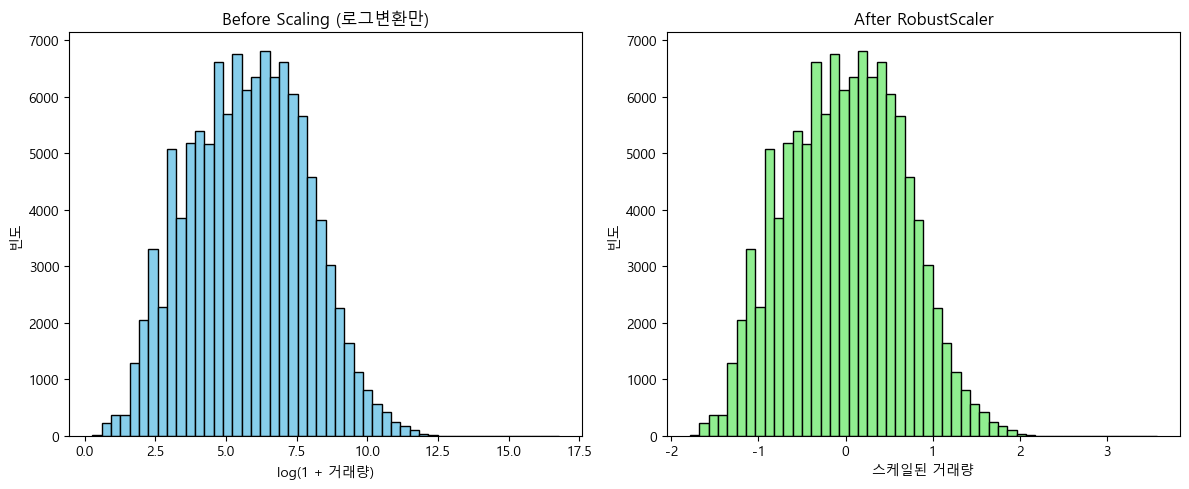

In [3]:
volume_raw = df["총거래량(kg)"].values.reshape(-1, 1)

# ✅ 로그 변환 (0 값 대응 위해 log1p)
volume_log = np.log1p(volume_raw)

# ✅ RobustScaler 적용
scaler = RobustScaler()
volume_scaled = scaler.fit_transform(volume_log)

# 📊 히스토그램
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(volume_log, bins=50, color='skyblue', edgecolor='black')
plt.title("Before Scaling (로그변환만)")
plt.xlabel("log(1 + 거래량)")
plt.ylabel("빈도")

plt.subplot(1, 2, 2)
plt.hist(volume_scaled, bins=50, color='lightgreen', edgecolor='black')
plt.title("After RobustScaler")
plt.xlabel("스케일된 거래량")
plt.ylabel("빈도")

plt.tight_layout()
plt.show()

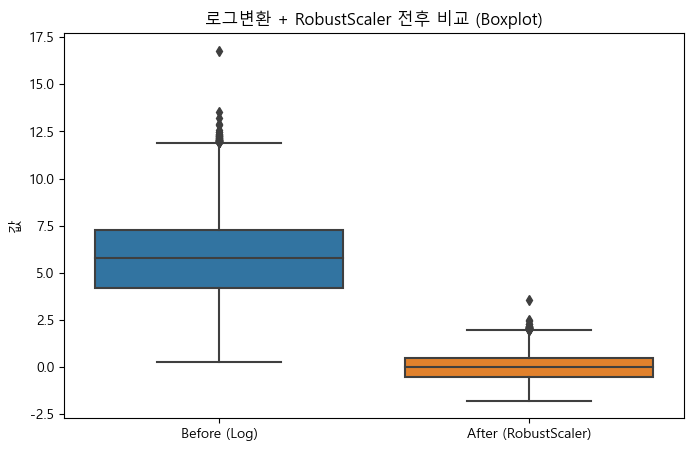

In [4]:
import seaborn as sns
plt.figure(figsize=(8, 5))
sns.boxplot(data=[volume_log.flatten(), volume_scaled.flatten()])
plt.xticks([0, 1], ['Before (Log)', 'After (RobustScaler)'])
plt.title("로그변환 + RobustScaler 전후 비교 (Boxplot)")
plt.ylabel("값")
plt.show()



C:\Users\Admin\AppData\Local\Temp\ipykernel_5104\1588247365.py:25: UserWarning: Glyph 128165 (\N{COLLISION SYMBOL}) missing from current font.
  plt.tight_layout()
c:\Users\Admin\anaconda3\envs\jikfam\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128165 (\N{COLLISION SYMBOL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


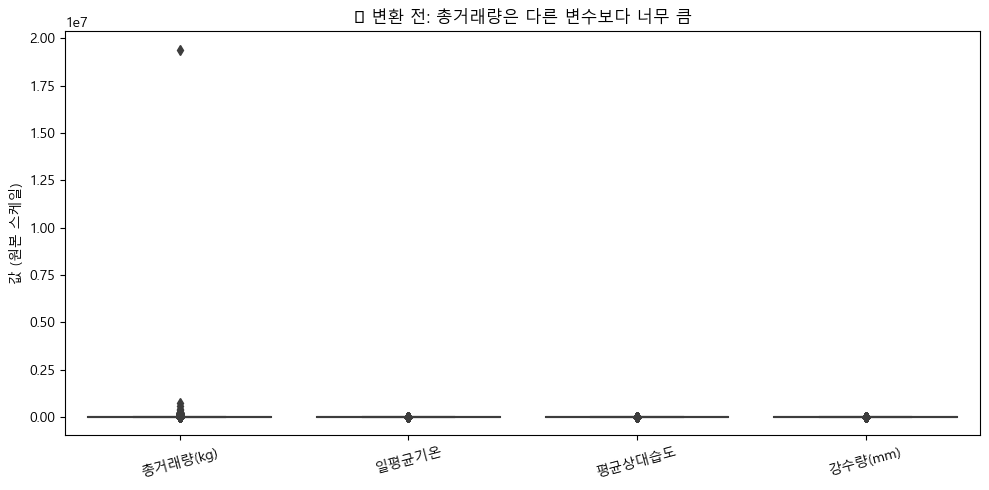

C:\Users\Admin\AppData\Local\Temp\ipykernel_5104\1588247365.py:40: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  plt.tight_layout()
c:\Users\Admin\anaconda3\envs\jikfam\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


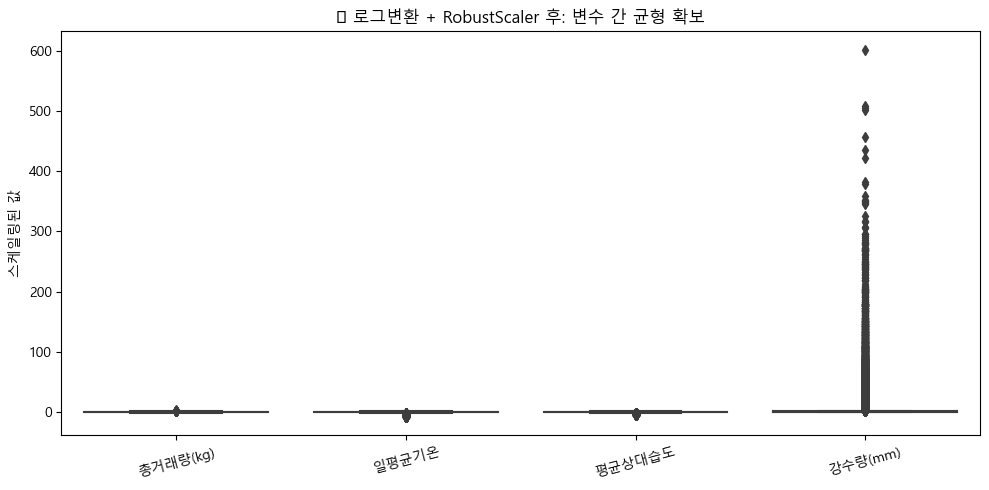

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler

# ✅ 예시용 데이터프레임
df_scaled = df.copy()

# 🎯 주요 수치형 변수들
target = '평균단가(원)'
exclude_cols = ['year', 'week', '품종코드', '등급코드', '직팜산지코드', target]
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
scale_cols = [col for col in numerical_cols if col not in exclude_cols]

# ✅ 비교할 변수들 (거래량 + 예시 변수들)
compare_cols = ['총거래량(kg)', '일평균기온', '평균상대습도', '강수량(mm)']

# 1️⃣ 변환 전 Boxplot
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_scaled[compare_cols])
plt.title("💥 변환 전: 총거래량은 다른 변수보다 너무 큼")
plt.ylabel("값 (원본 스케일)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# 2️⃣ 로그 + 스케일링
df_scaled['총거래량(kg)'] = np.log1p(df_scaled['총거래량(kg)'])

scaler = RobustScaler()
df_scaled[compare_cols] = scaler.fit_transform(df_scaled[compare_cols])

# 2️⃣ 변환 후 Boxplot
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_scaled[compare_cols])
plt.title("✅ 로그변환 + RobustScaler 후: 변수 간 균형 확보")
plt.ylabel("스케일링된 값")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


<Axes: xlabel='총거래량(kg)'>

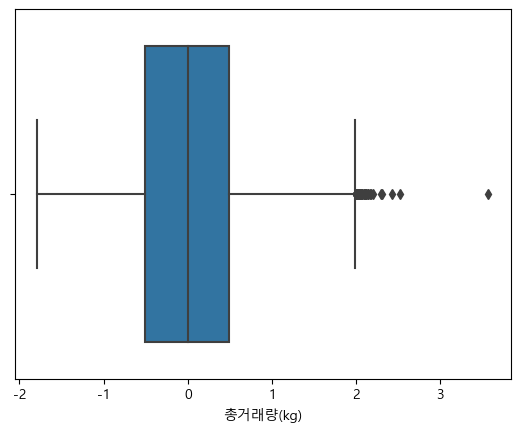

In [16]:
# 이상치 탐색용
import seaborn as sns
sns.boxplot(x=df_scaled['총거래량(kg)'])


[이상치 개수] : 45개

[상위 5개 이상치]
       week_start  총거래량(kg)  총거래량(kg)_scaled
696    2018-02-26  150000.0         1.993540
2188   2018-04-16  154880.0         2.003923
3938   2018-05-21  172907.0         2.039630
4426   2018-05-28  202272.0         2.090502
18346  2019-05-13  163957.0         2.022393


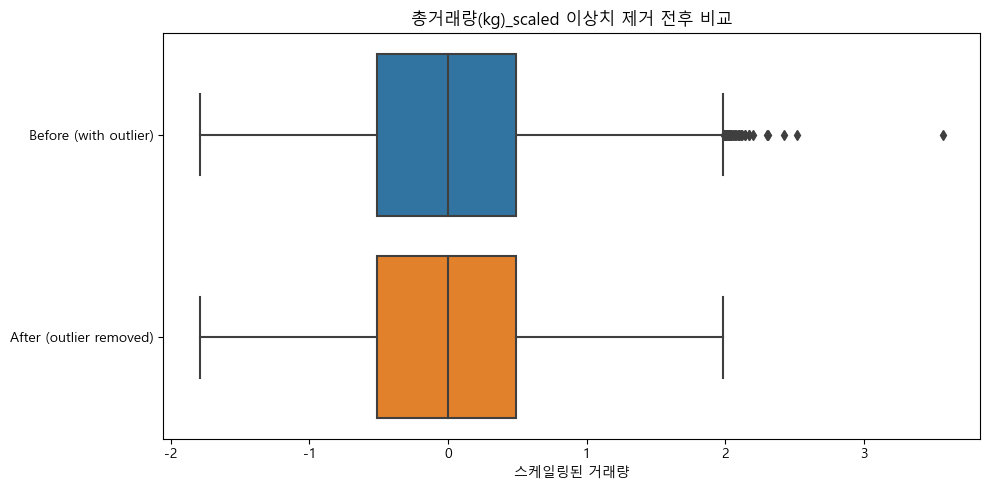

In [18]:
# 2️⃣ 로그변환 + RobustScaler 적용
df['총거래량(kg)_log'] = np.log1p(df['총거래량(kg)'])
scaler = RobustScaler()
df['총거래량(kg)_scaled'] = scaler.fit_transform(df[['총거래량(kg)_log']])

# 3️⃣ IQR 방식으로 이상치 탐지
def detect_outliers_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return series[(series < lower) | (series > upper)]

outliers = detect_outliers_iqr(df['총거래량(kg)_scaled'])

# 4️⃣ 이상치 정보 출력
print(f"[이상치 개수] : {len(outliers)}개")
print("\n[상위 5개 이상치]")
print(df.loc[outliers.index, ['week_start', '총거래량(kg)', '총거래량(kg)_scaled']].head())

# 5️⃣ 이상치 제거
df_cleaned = df.drop(index=outliers.index)

# 6️⃣ Boxplot 비교 시각화
plt.figure(figsize=(10, 5))
sns.boxplot(data=[df['총거래량(kg)_scaled'], df_cleaned['총거래량(kg)_scaled']], orient='h')
plt.yticks([0, 1], ['Before (with outlier)', 'After (outlier removed)'])
plt.title("총거래량(kg)_scaled 이상치 제거 전후 비교")
plt.xlabel("스케일링된 거래량")
plt.tight_layout()
plt.show()

C:\Users\bdh99\AppData\Local\Temp\ipykernel_10632\570080950.py:9: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from current font.
  plt.tight_layout()
c:\Users\bdh99\anaconda3\envs\jikfam\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


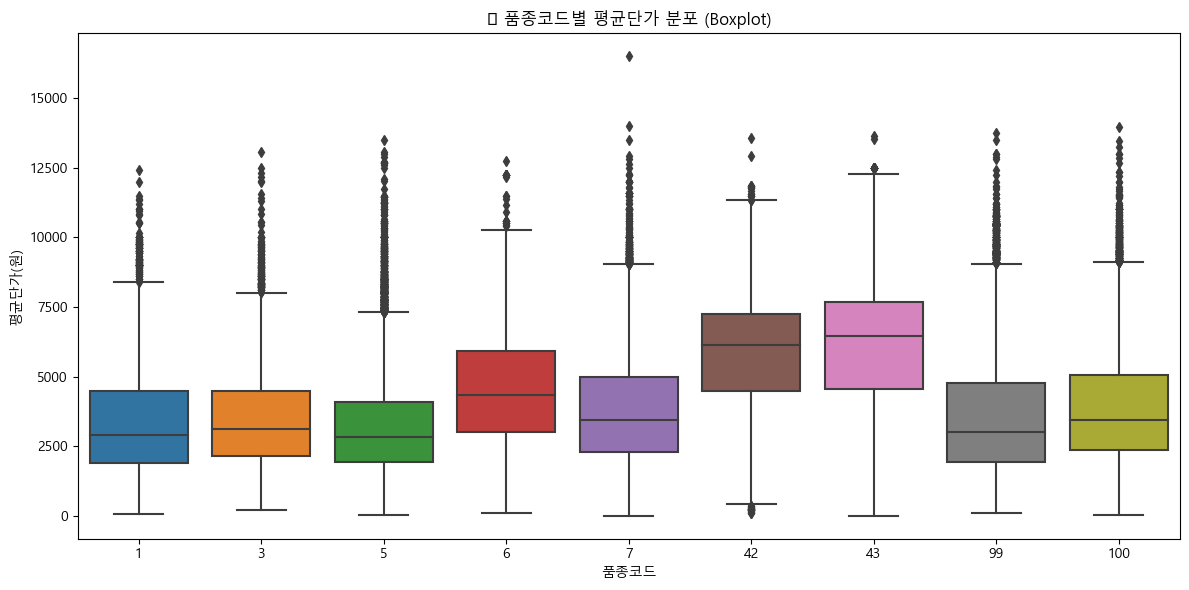

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='품종코드', y='평균단가(원)')
plt.title("📦 품종코드별 평균단가 분포 (Boxplot)")
plt.xlabel("품종코드")
plt.ylabel("평균단가(원)")
plt.tight_layout()
plt.show()


C:\Users\bdh99\AppData\Local\Temp\ipykernel_10632\420509624.py:6: UserWarning: Glyph 128666 (\N{DELIVERY TRUCK}) missing from current font.
  plt.tight_layout()
c:\Users\bdh99\anaconda3\envs\jikfam\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128666 (\N{DELIVERY TRUCK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


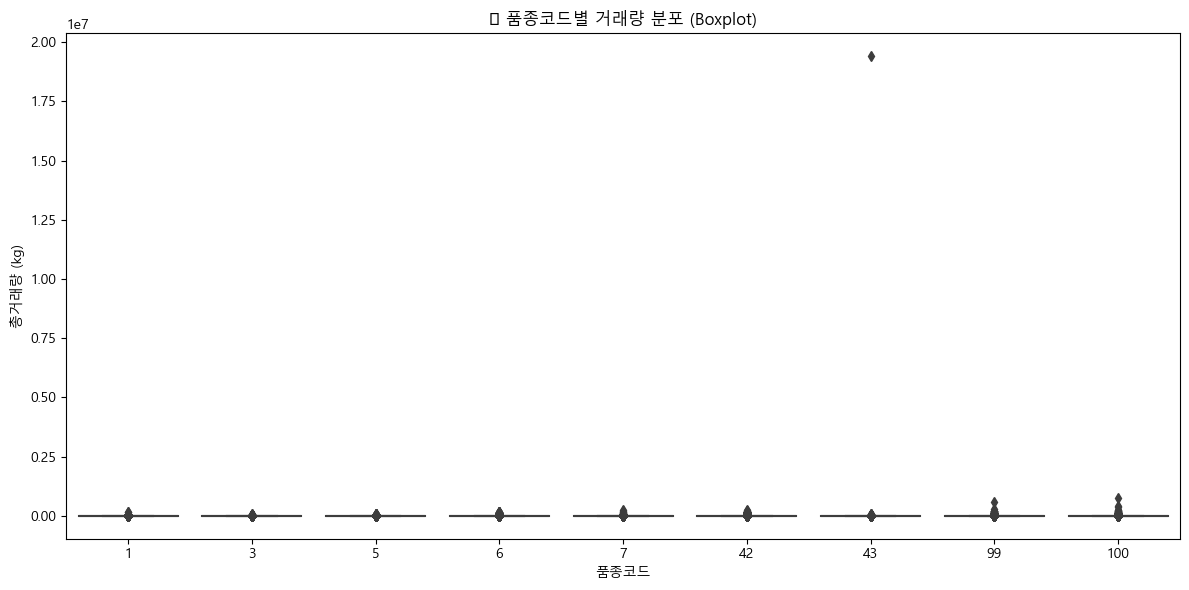

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='품종코드', y='총거래량(kg)')
plt.title("🚚 품종코드별 거래량 분포 (Boxplot)")
plt.xlabel("품종코드")
plt.ylabel("총거래량 (kg)")
plt.tight_layout()
plt.show()


C:\Users\bdh99\AppData\Local\Temp\ipykernel_10632\2565174899.py:7: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
c:\Users\bdh99\anaconda3\envs\jikfam\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


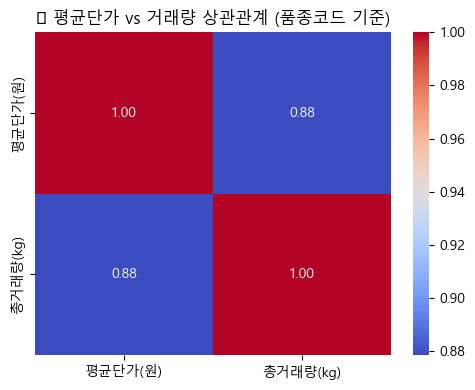

In [7]:
# 품종코드별 평균 요약
pivot_df = df.groupby('품종코드')[['평균단가(원)', '총거래량(kg)']].mean().corr()

plt.figure(figsize=(5, 4))
sns.heatmap(pivot_df, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("📊 평균단가 vs 거래량 상관관계 (품종코드 기준)")
plt.tight_layout()
plt.show()
